# Final Project

This notebook is adapted from here: https://aiqm.github.io/torchani/examples/nnp_training.html

## Checkpoint 1: Data preparation

1. Create a working directory: `/global/scratch/users/[USER_NAME]/[DIR_NAME]`. Replace the [USER_NAME] with yours and specify a [DIR_NAME] you like.
2. Copy the Jupyter Notebook to the working directory
3. Download the ANI dataset `ani_dataset_gdb_s01_to_s04.h5` from bCourses and upload it to the working directory

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
import numpy as np
from tqdm import tqdm
import torch
import torch.nn as nn
import torchani
import matplotlib.pyplot as plt

### Use GPU

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


### Set up AEV computer

#### AEV: Atomic Environment Vector (atomic features)

Ref: Chem. Sci., 2017, 8, 3192

In [4]:
def init_aev_computer():
    Rcr = 5.2
    Rca = 3.5
    EtaR = torch.tensor([16], dtype=torch.float, device=device)
    ShfR = torch.tensor([
        0.900000, 1.168750, 1.437500, 1.706250, 
        1.975000, 2.243750, 2.512500, 2.781250, 
        3.050000, 3.318750, 3.587500, 3.856250, 
        4.125000, 4.393750, 4.662500, 4.931250
    ], dtype=torch.float, device=device)


    EtaA = torch.tensor([8], dtype=torch.float, device=device)
    Zeta = torch.tensor([32], dtype=torch.float, device=device)
    ShfA = torch.tensor([0.90, 1.55, 2.20, 2.85], dtype=torch.float, device=device)
    ShfZ = torch.tensor([
        0.19634954, 0.58904862, 0.9817477, 1.37444680, 
        1.76714590, 2.15984490, 2.5525440, 2.94524300
    ], dtype=torch.float, device=device)

    num_species = 4
    aev_computer = torchani.AEVComputer(
        Rcr, Rca, EtaR, ShfR, EtaA, Zeta, ShfA, ShfZ, num_species
    )
    return aev_computer

aev_computer = init_aev_computer()
aev_dim = aev_computer.aev_length
print(aev_dim)

384


### Prepare dataset & split

In [5]:
def load_ani_dataset(dspath):
    self_energies = torch.tensor([
        0.500607632585, -37.8302333826,
        -54.5680045287, -75.0362229210
    ], dtype=torch.float, device=device)
    energy_shifter = torchani.utils.EnergyShifter(None)
    species_order = ['H', 'C', 'N', 'O']

    dataset = torchani.data.load(dspath)
    dataset = dataset.subtract_self_energies(energy_shifter, species_order)
    dataset = dataset.species_to_indices(species_order)
    dataset = dataset.shuffle()
    return dataset

dataset = load_ani_dataset("../Desktop/bioengc142/Datasets/ani_gdb_s01_to_s04.h5")
# Use dataset.split method to do split
train_data, val_data, test_data = dataset.split(0.8, 0.1, 0.1)

### Batching

In [ ]:
batch_size = 8192
# use dataset.collate(...).cache() method to do batching
train_data_loader = train_data.collate(batch_size).cache()
val_data_loader = val_data.collate(batch_size).cache()
test_data_loader = test_data.collate(batch_size).cache()


### Torchani API

In [7]:
class AtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = AtomicNet()
net_C = AtomicNet()
net_N = AtomicNet()
net_O = AtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H,net_C,net_N,net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

In [8]:
train_data_batch = next(iter(train_data_loader))

loss_func = nn.MSELoss()
species = train_data_batch['species'].to(device)
coords = train_data_batch['coordinates'].to(device)
true_energies = train_data_batch['energies'].to(device).float()
_, pred_energies = model((species, coords))
loss = loss_func(true_energies, pred_energies)
print(loss)

tensor(0.0174, grad_fn=<MseLossBackward0>)


## Checkpoint 2: Network construction and workflow development

In [9]:
class ANITrainer:
    def __init__(self, model, batch_size, learning_rate, epoch, l2):
        self.model = model
        
        num_params = sum(item.numel() for item in model.parameters())
        print(f"{model.__class__.__name__} - Number of parameters: {num_params}")
        
        self.batch_size = batch_size
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=l2)
        self.epoch = epoch
    
    def train(self, train_data, val_data, early_stop=True, draw_curve=True):
        self.model.train()
        
        # init data loader
        print("Initialize training data...")
        train_data_loader = train_data.collate(self.batch_size).cache()
        
        # definition of loss function: MSE is a good choice! 
        loss_func = nn.MSELoss()
        
        # record epoch losses
        train_loss_list = []
        val_loss_list = []
        lowest_val_loss = np.inf
        
        for i in tqdm(range(self.epoch), leave=True):
            train_epoch_loss = 0.0
            for train_data_batch in train_data_loader:
                
                # compute energies
                #...
                species=train_data_batch['species'].to(device)
                X_batch, y_batch=train_data_batch['coordinates'].to(device), train_data_batch['energies'].to(device).float()
                _, y_pred = self.model((species,X_batch))
                
                # compute loss
                batch_loss = loss_func(y_pred, y_batch) #...
                
                # do a step
                #...
                self.optimizer.zero_grad()
                batch_loss.backward()
                self.optimizer.step()
                
                batch_importance = y_batch.shape[0] / len(train_data) #...
                train_epoch_loss += batch_importance * batch_loss.item() #...
            
            # use the self.evaluate to get loss on the validation set 
            val_epoch_loss = self.evaluate(val_data) #...
            
            # append the losses
            #...
            train_loss_list.append(train_epoch_loss)
            val_loss_list.append(val_epoch_loss)
            
            if early_stop:
                if val_epoch_loss < lowest_val_loss:
                    lowest_val_loss = val_epoch_loss
                    weights = self.model.state_dict()
        
        if draw_curve:
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.set_yscale("log")
            # Plot train loss and validation loss
            ax.plot(np.arange(self.epoch), train_loss_list, label='Train') #...
            ax.plot(np.arange(self.epoch), val_loss_list, label='Validation') #...
            ax.legend()
            ax.set_xlabel("# Batch")
            ax.set_ylabel("Loss")
        
        if early_stop:
            self.model.load_state_dict(weights)
        
        return train_loss_list, val_loss_list
    
    
    def evaluate(self, data, draw_plot=False):
        
        # init data loader
        data_loader = data.collate(self.batch_size).cache()
        
        # init loss function
        loss_func = nn.MSELoss()
        total_loss = 0.0
        
        if draw_plot:
            true_energies_all = []
            pred_energies_all = []
            
        with torch.no_grad():
            for batch_data in data_loader:
                
                # compute energies
                #...
                species=batch_data['species'].to(device)
                X_batch, true_energies=batch_data['coordinates'].to(device),batch_data['energies'].to(device).float()
                _, pred_energies = self.model((species,X_batch))
                
                # compute loss
                batch_loss = loss_func(pred_energies, true_energies) #...

                batch_importance = true_energies.shape[0] / len(data) #...
                total_loss += batch_importance * batch_loss.item() #...
                
                if draw_plot:
                    true_energies_all.append(true_energies.detach().cpu().numpy().flatten())
                    pred_energies_all.append(pred_energies.detach().cpu().numpy().flatten())

        if draw_plot:
            true_energies_all = np.concatenate(true_energies_all)
            pred_energies_all = np.concatenate(pred_energies_all)
            # Report the mean absolute error
            # The unit of energies in the dataset is hartree
            # please convert it to kcal/mol when reporting the mean absolute error
            # 1 hartree = 627.5094738898777 kcal/mol
            # MAE = mean(|true - pred|)
            hartree2kcalmol = 627.5094738898777
            mae = np.mean(np.abs(true_energies_all-pred_energies_all))*hartree2kcalmol #...
            fig, ax = plt.subplots(1, 1, figsize=(5, 4), constrained_layout=True)
            ax.scatter(true_energies_all, pred_energies_all, label=f"MAE: {mae:.2f} kcal/mol", s=2)
            ax.set_xlabel("Ground Truth")
            ax.set_ylabel("Predicted")
            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()
            vmin, vmax = min(xmin, ymin), max(xmax, ymax)
            ax.set_xlim(vmin, vmax)
            ax.set_ylim(vmin, vmax)
            ax.plot([vmin, vmax], [vmin, vmax], color='red')
            ax.legend()
            
        return total_loss
        

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [36:42<00:00, 110.11s/it]


1.7412704043370385e-05

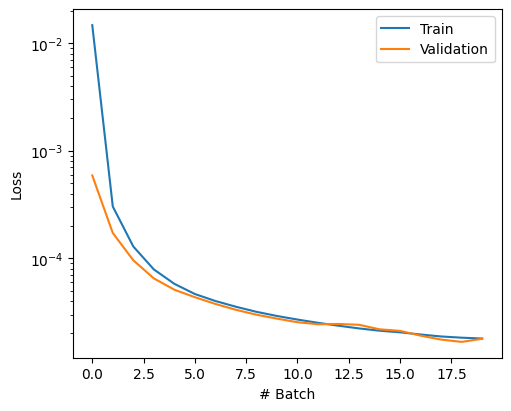

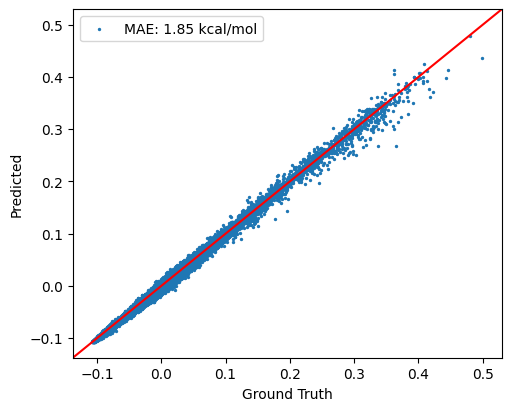

In [11]:
trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=0.0)
trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

### L2 regularization strategies

l2=1e-4

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [37:02<00:00, 111.12s/it]


4.909878103605102e-05

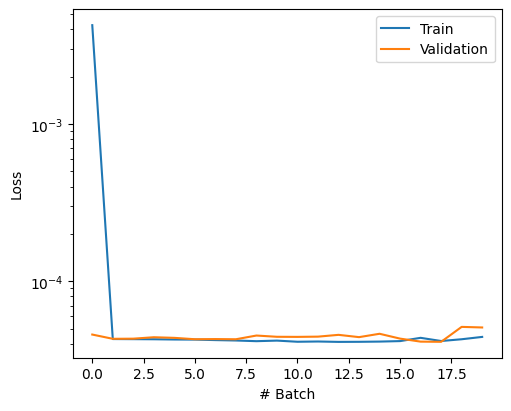

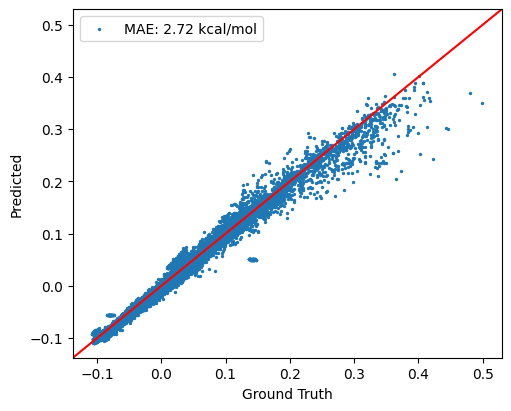

In [12]:
trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-4)
trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

l2=1e-5

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [37:59<00:00, 113.97s/it]


1.6008272025640155e-05

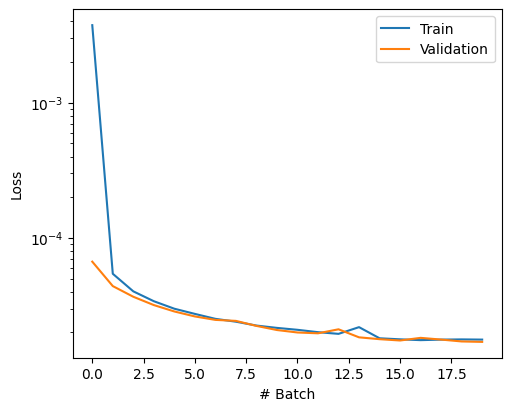

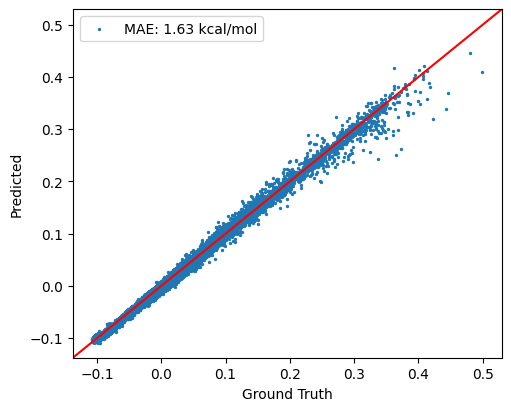

In [13]:
trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-5)
trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

l2=1e-6

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [37:56<00:00, 113.83s/it]


7.753681263041946e-06

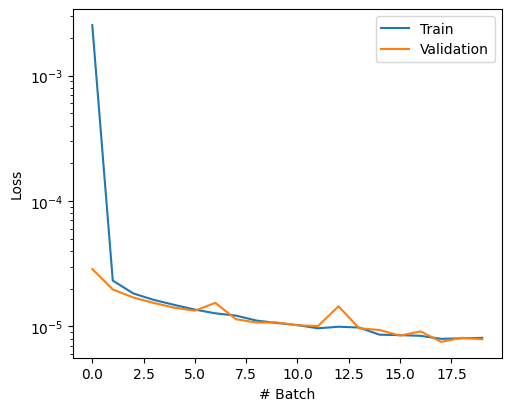

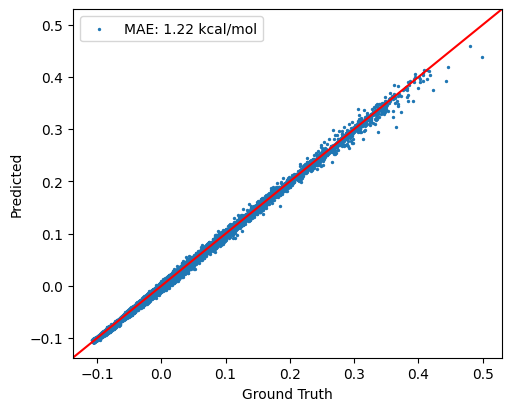

In [14]:
trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-6)
trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

### Hyperparameter tuning: learning rate

lr = 1e-4

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [39:02<00:00, 117.13s/it]


4.884573845625562e-06

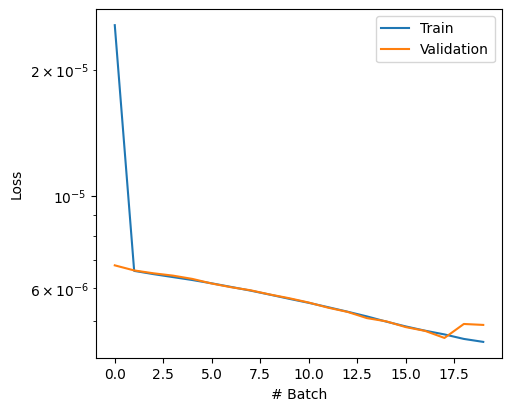

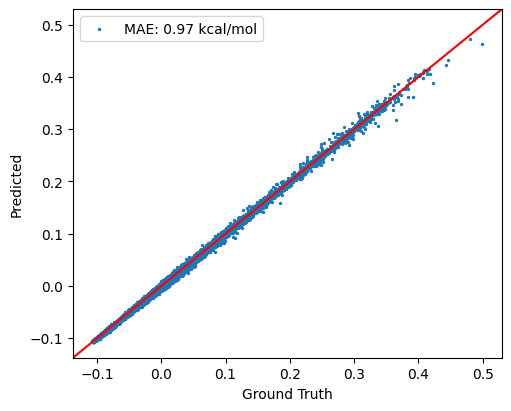

In [15]:
trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-4, epoch=20, l2=0.0)
trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

### Play with model architecture

add more layers

In [16]:
class MoreLayersAtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = MoreLayersAtomicNet()
net_C = MoreLayersAtomicNet()
net_N = MoreLayersAtomicNet()
net_O = MoreLayersAtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H,net_C,net_N,net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

Sequential - Number of parameters: 526340
Initialize training data...


100%|██████████| 20/20 [44:47<00:00, 134.39s/it]


2.1703428817052022e-05

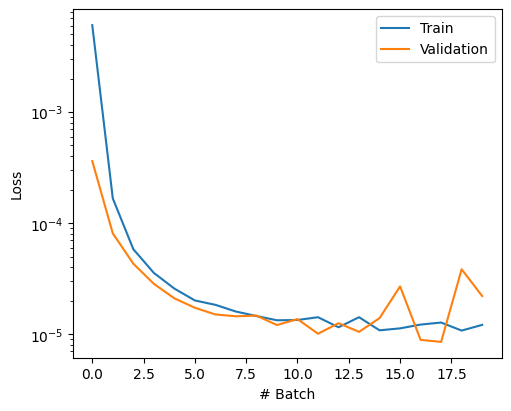

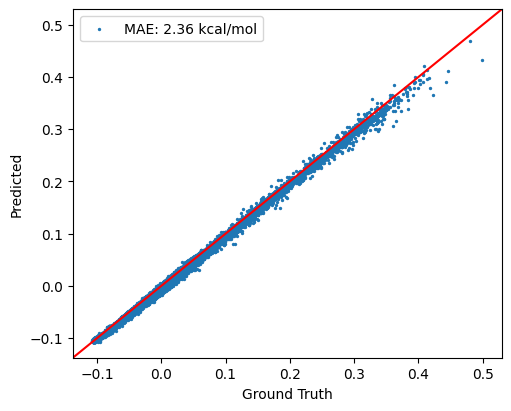

In [17]:
trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-6)
trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

add batchnorm

In [18]:
class BatchNormAtomicNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(384, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.layers(x)

net_H = BatchNormAtomicNet()
net_C = BatchNormAtomicNet()
net_N = BatchNormAtomicNet()
net_O = BatchNormAtomicNet()

# ANI model requires a network for each atom type
# use torch.ANIModel() to compile atomic networks
ani_net = torchani.ANIModel([net_H,net_C,net_N,net_O])
model = nn.Sequential(
    aev_computer,
    ani_net
).to(device)

Sequential - Number of parameters: 198660
Initialize training data...


100%|██████████| 20/20 [40:43<00:00, 122.18s/it]


0.00022829828510018005

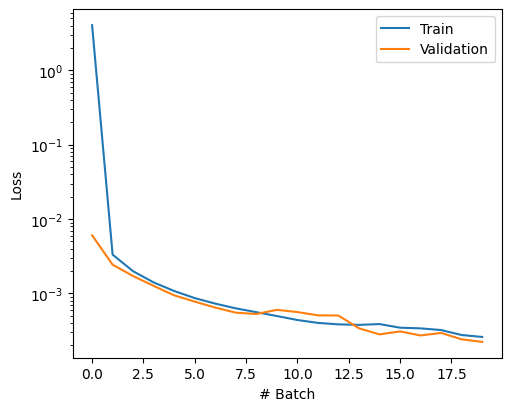

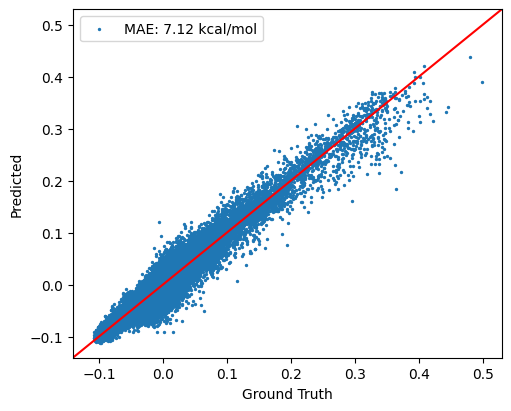

In [19]:
trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-2, epoch=20, l2=1e-6)
trainer.train(train_data, val_data, early_stop=True, draw_curve=True)
trainer.evaluate(test_data, draw_plot=True)

### Selecting final choice of model

The original AtomicNet with a batch size of 8192, learning_rate of 1e-3, 20 epochs, and l2 regularization of 1e-6 had the lowest MAE (1.21 kcal/mol) and smoothest training/validation curve and therefore we can select this as the final choice of model.

## Checkpoint 4: Final production mode

### multiple runs

In [10]:
maes = []

for seed in range(5):
    #torch.manual_seed(seed)
    #np.random.seed(seed)
    
    net_H = AtomicNet()
    net_C = AtomicNet()
    net_N = AtomicNet()
    net_O = AtomicNet()
    
    ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
    model = nn.Sequential(aev_computer, ani_net).to(device)

    trainer = ANITrainer(model, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-6)
    trainer.train(train_data, val_data, early_stop=True, draw_curve=False)
    mae = trainer.evaluate(test_data, draw_plot=False)
    maes.append(mae)

print("MAEs over 5 runs (hartree):", maes)
print("Mean MAE (kcal/mol):", np.mean(maes) * 627.5094738898777)
print("Std Dev MAE (kcal/mol):", np.std(maes) * 627.5094738898777)

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [38:25<00:00, 115.29s/it]


Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [37:15<00:00, 111.76s/it]


Sequential - Number of parameters: 197636
Initialize training data...


...

Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [37:09<00:00, 111.50s/it]


Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [37:01<00:00, 111.06s/it]


MAEs over 5 runs (hartree): [1.7182889530026318e-05, 1.3453854736425495e-05, 1.5300385179085512e-05, 2.4824813757450477e-05, 1.4631849530480111e-05]
Mean MAE (kcal/mol): 0.010717082790327941
Std Dev MAE (kcal/mol): 0.002545896770343272


### N-fold cross-validation

In [23]:
from sklearn.model_selection import KFold


In [ ]:
def cross_validate_ani(dataset, n_splits=5, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-6, device='cuda'):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_results = []
    dataset_list = list(dataset)

    for fold, (train_idx, test_idx) in enumerate(kf.split(dataset_list)):
        print(f"\nFold {fold + 1}/{n_splits}")
        train_data, val_data, test_data = dataset.split(0.8, 0.1, 0.1)
        train_loader = train_data.collate(batch_size).cache()
        val_loader = val_data.collate(batch_size).cache()
        test_loader = test_data.collate(batch_size).cache()

        aev_computer = init_aev_computer()
        net_H = AtomicNet()
        net_C = AtomicNet()
        net_N = AtomicNet()
        net_O = AtomicNet()
        ani_net = torchani.ANIModel([net_H, net_C, net_N, net_O])
        model = nn.Sequential(aev_computer, ani_net).to(device)

        trainer = ANITrainer(
            model=model,
            batch_size=batch_size,
            learning_rate=learning_rate,
            epoch=epoch,
            l2=l2
        )

        trainer.train(train_data, val_data, early_stop=True, draw_curve=False)

        test_loss = trainer.evaluate(test_data, draw_plot=False)
        print(f"Fold {fold + 1} Test Loss: {test_loss:.6f}")

        fold_results.append(test_loss)

    avg_loss = np.mean(fold_results)
    std_loss = np.std(fold_results)
    print(f"\nCross-validation results: Average Test Loss = {avg_loss:.6f}, Std = {std_loss:.6f}")

    return fold_results

In [ ]:

cross_validate_ani(dataset, n_splits=3, batch_size=8192, learning_rate=1e-3, epoch=20, l2=1e-6, device=device)


Fold 1/3
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [35:20<00:00, 106.00s/it]


Fold 1 Test Loss: 0.000020

Fold 2/3
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [35:13<00:00, 105.70s/it]


Fold 2 Test Loss: 0.000044

Fold 3/3
Sequential - Number of parameters: 197636
Initialize training data...


100%|██████████| 20/20 [35:04<00:00, 105.24s/it]


Fold 3 Test Loss: 0.000016

Cross-validation results: Average Test Loss = 0.000026, Std = 0.000012


[1.970111947595433e-05, 4.377217052984357e-05, 1.5652939027545566e-05]